# 06 — Clustered binary medical response with a GLMM

This tutorial models a binary response for patients nested in clinics. A Bernoulli-logit generalized linear mixed model accounts for clinic-level intercept heterogeneity using the supported Laplace reference path.

## Objectives

- Simulate deterministic clustered binary outcomes.
- Select the Bernoulli family and logit link through a public family object.
- Compile and fit a random-intercept Laplace GLMM.
- Translate log-odds coefficients to conditional odds ratios.
- Inspect simple observed-versus-fitted summaries and honest approximation limits.

In [1]:
import importlib
import logging

import numpy as np
from scipy.special import expit

import pymixef

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

plt.style.use("tableau-colorblind10")

SEED = 20260706
rng = np.random.default_rng(SEED)

## Generate a clinic-clustered dataset

Fourteen clinics each enroll twelve patients. Treatment is balanced within clinic. The generating model adds a clinic-specific random log-odds intercept before drawing Bernoulli responses.

In [2]:
n_clinics = 14
patients_per_clinic = 12
clinic_index = np.repeat(np.arange(n_clinics), patients_per_clinic)
n_rows = len(clinic_index)

treatment = np.tile(np.array([0, 1] * 6), n_clinics)
baseline_score = rng.normal(0.0, 1.0, n_rows)
clinic_intercept = rng.normal(0.0, 0.55, n_clinics)
linear_predictor = -0.55 + 0.80 * treatment + 0.45 * baseline_score + clinic_intercept[clinic_index]
generating_probability = expit(linear_predictor)
response = rng.binomial(1, generating_probability)

data = {
    "response": response,
    "treatment": treatment,
    "baseline_score": baseline_score,
    "clinic": np.array([f"C{i + 1:02d}" for i in clinic_index]),
}

{
    "rows": n_rows,
    "clinics": n_clinics,
    "observed_response_rate": float(np.mean(response)),
}

{'rows': 168, 'clinics': 14, 'observed_response_rate': 0.39880952380952384}

## Compile before fitting

The non-Gaussian family selects the generalized mixed-model path. PyMixEF's current reference GLMM supports Bernoulli, binomial, Poisson, and negative-binomial-2 likelihoods with a Laplace approximation. It does not silently replace adaptive quadrature with Laplace.

In [3]:
model = pymixef.Model.from_formula(
    "response ~ treatment + baseline_score + (1 | clinic)",
    family=pymixef.families.Bernoulli(),
)
plan = model.compile(
    data,
    engine="glmm",
    method="laplace",
    maxiter=250,
    compute_hessian=False,
)
print(plan.explain())

Formula: response ~ treatment + baseline_score + (1 | clinic)
Response: response (168 analysis rows)
Fixed design: X(168, 3), rank=3, columns=['Intercept', 'treatment', 'baseline_score']
Random designs:
  clinic: Z(168, 1), groups=14, covariance=unstructured
Excluded source rows: 0
Family: bernoulli (logit link)
Engine: glmm; method: laplace
Model IR: c0306b40e2ee9601ce466dd518bf43684133ca7fe8b657721e4f7a8ae864e94e
Data audit: 168 input, 168 analysis, 0 excluded; reasons={'DATA-RETAINED-001': 168}


In [4]:
fit = plan.fit()
assert fit.convergence.trustworthy, fit.convergence.to_dict()
print(fit.summary())
print("\nApproximation:", fit.extra["approximation"])
print("Quadrature order recorded:", fit.extra["quadrature_order"])
print("Convergence trustworthy:", fit.convergence.trustworthy)

PyMixEF fit (laplace, laplace)
Observations: 168
Objective: 106.5094795
Log likelihood: -106.5094795
Convergence: converged
Parameters:
  Intercept             -0.98360725
  treatment              1.0520858
  baseline_score         0.18998408
  sd(clinic:Intercept)   0.56925206

Approximation: first-order Laplace at the joint conditional mode
Quadrature order recorded: 1
Convergence trustworthy: True


## Conditional odds-ratio interpretation

Exponentiating a logit coefficient gives a subject/cluster-conditional odds ratio, holding the other predictors and clinic random intercept fixed. It is not a marginal risk ratio or risk difference.

In [5]:
conditional_odds_ratios = {
    name: float(np.exp(value))
    for name, value in fit.parameters.items()
    if name in {"treatment", "baseline_score"}
}
assert conditional_odds_ratios["treatment"] > 1.0, "Expected the generated benefit"
print("Conditional odds ratios:", conditional_odds_ratios)
print("Clinic random-intercept SD:", fit.parameters["sd(clinic:Intercept)"])
print("Synthetic treatment-direction check: passed")

Conditional odds ratios: {'treatment': 2.863617891182583, 'baseline_score': 1.2092303514690166}
Clinic random-intercept SD: 0.5692520623280747
Synthetic treatment-direction check: passed


## Model-implied response curves

Transforming the fixed-effects linear predictor through the inverse-logit gives response probabilities at a clinic random effect of zero. Plotting both arms across baseline scores makes the model scale tangible.

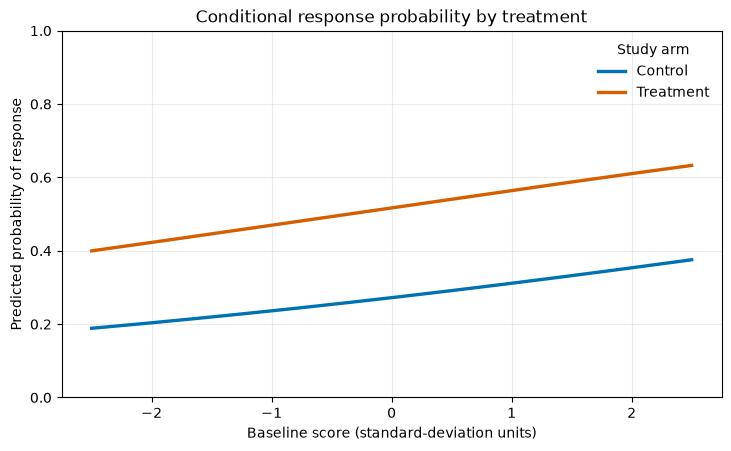

In [6]:
baseline_grid = np.linspace(-2.5, 2.5, 200)
curve_colors = {0: "#0072B2", 1: "#D55E00"}

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for arm, label in ((0, "Control"), (1, "Treatment")):
    curve_linear_predictor = (
        fit.parameters["Intercept"]
        + arm * fit.parameters["treatment"]
        + baseline_grid * fit.parameters["baseline_score"]
    )
    ax.plot(
        baseline_grid,
        expit(curve_linear_predictor),
        color=curve_colors[arm],
        linewidth=2.4,
        label=label,
    )
ax.set(
    title="Conditional response probability by treatment",
    xlabel="Baseline score (standard-deviation units)",
    ylabel="Predicted probability of response",
    ylim=(0.0, 1.0),
)
ax.legend(title="Study arm", frameon=False)
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** Treatment shifts the conditional probability curve upward throughout the displayed baseline range. These curves set the clinic random intercept to zero, so they are conditional rather than population-marginal predictions.

## A compact fitted-probability check

The archived fitted values are conditional fitted probabilities for the analysis rows. Aggregating them by treatment is a basic descriptive check, not a calibration study.

In [7]:
arm_summary = {}
for arm in (0, 1):
    selected = treatment == arm
    arm_summary[arm] = {
        "n": int(np.count_nonzero(selected)),
        "observed_rate": float(np.mean(response[selected])),
        "mean_fitted_probability": float(np.mean(fit.fitted_values[selected])),
    }
arm_summary

{0: {'n': 84,
  'observed_rate': 0.2857142857142857,
  'mean_fitted_probability': 0.2798923202964317},
 1: {'n': 84,
  'observed_rate': 0.5119047619047619,
  'mean_fitted_probability': 0.5140566349218681}}

## Descriptive calibration

Grouping conditional fitted probabilities into five fixed-width bins compares average prediction with the observed response rate. Point size shows how many patients contribute to each nonempty bin.

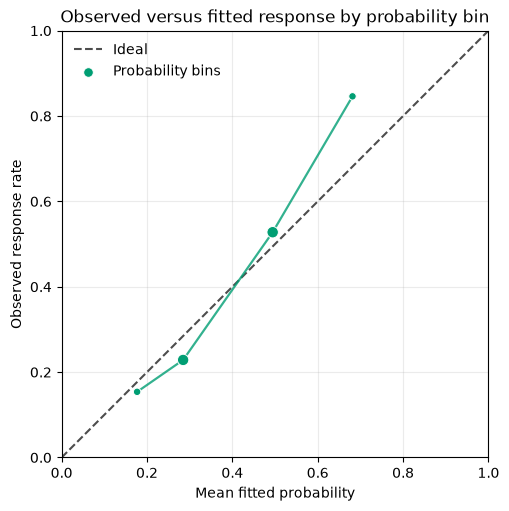

In [8]:
calibration_edges = np.linspace(0.0, 1.0, 6)
calibration_bin = np.digitize(fit.fitted_values, calibration_edges[1:-1])
calibration_predicted = []
calibration_observed = []
calibration_counts = []
for bin_number in range(5):
    selected = calibration_bin == bin_number
    if np.any(selected):
        calibration_predicted.append(float(np.mean(fit.fitted_values[selected])))
        calibration_observed.append(float(np.mean(response[selected])))
        calibration_counts.append(int(np.count_nonzero(selected)))

fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)
ax.plot([0.0, 1.0], [0.0, 1.0], color="#4D4D4D", linestyle="--", label="Ideal")
ax.plot(
    calibration_predicted,
    calibration_observed,
    color="#009E73",
    linewidth=1.6,
    alpha=0.8,
)
ax.scatter(
    calibration_predicted,
    calibration_observed,
    s=8 * np.sqrt(calibration_counts),
    color="#009E73",
    edgecolor="white",
    linewidth=0.7,
    label="Probability bins",
    zorder=3,
)
ax.set(
    title="Observed versus fitted response by probability bin",
    xlabel="Mean fitted probability",
    ylabel="Observed response rate",
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
    aspect="equal",
)
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** The binned points remain reasonably close to the diagonal for this synthetic dataset. This compact in-sample check is useful for orientation; external or cross-validated calibration would be needed for predictive claims.

## Clinic random-effect caterpillar

Conditional modes summarize clinic-specific log-odds shifts after accounting for treatment and baseline score. Laplace conditional standard deviations provide an uncertainty display around each shrunken mode.

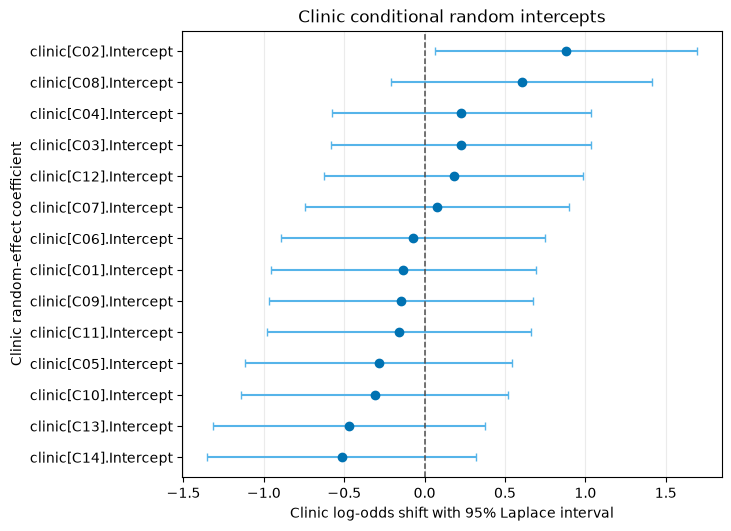

In [9]:
random_effect_diagnostics = fit.diagnostic("random_effects")
clinic_names = np.asarray(random_effect_diagnostics.columns["name"], dtype=str)
clinic_modes = np.asarray(random_effect_diagnostics.columns["conditional_mode"], dtype=float)
clinic_standard_deviations = np.asarray(
    random_effect_diagnostics.columns["conditional_sd_laplace"], dtype=float
)
clinic_order = np.argsort(clinic_modes)
clinic_positions = np.arange(len(clinic_order))

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
ax.errorbar(
    clinic_modes[clinic_order],
    clinic_positions,
    xerr=1.96 * clinic_standard_deviations[clinic_order],
    fmt="o",
    color="#0072B2",
    ecolor="#56B4E9",
    capsize=3,
    markersize=6,
)
ax.axvline(0.0, color="#4D4D4D", linestyle="--", linewidth=1.1)
ax.set_yticks(clinic_positions, clinic_names[clinic_order])
ax.set(
    title="Clinic conditional random intercepts",
    xlabel="Clinic log-odds shift with 95% Laplace interval",
    ylabel="Clinic random-effect coefficient",
)
ax.grid(axis="x", alpha=0.25)
plt.show()

**Interpretation.** Clinic modes vary around zero and their intervals overlap substantially, consistent with partial pooling. They are conditional model summaries rather than independently estimated clinic performance scores.

## Inspect an unsupported choice without optimizing

Validation exposes that AGHQ is not implemented rather than silently changing the requested method.

In [10]:
aghq_validation = model.validate(engine="aghq")
assert not aghq_validation.valid
assert any(item.code == "ENGINE-METHOD-002" for item in aghq_validation.findings)
{
    "valid": aghq_validation.valid,
    "engine": aghq_validation.engine,
    "method": aghq_validation.method,
    "findings": [item.to_dict() for item in aghq_validation.findings],
}

{'valid': False,
 'engine': 'glmm',
 'method': 'aghq',
 'findings': [{'code': 'ENGINE-METHOD-002',
   'severity': 'error',
   'message': 'The reference GLMM engine implements Laplace only; AGHQ is not silently substituted.',
   'component': 'method',
   'suggested_engines': ['glmm']}]}

## Scope note

This showcase uses the dense experimental first-order Laplace reference engine and intentionally omits Hessian-based intervals. The capability report records current implementation limitations; for clinical use, assess approximation sensitivity and remember that the displayed conditional odds ratios are not marginal treatment effects.

## Exercises

1. Increase the clinic random-intercept standard deviation in the generator and compare the fitted component.
2. Reduce patients per clinic to explore when the Laplace approximation becomes less stable.
3. Replace Bernoulli outcomes with counts and use `pymixef.families.Poisson()`.
4. Re-enable the Hessian, inspect convergence diagnostics, and avoid treating optimizer termination alone as proof of trustworthy inference.